In [1]:
import sys

print(sys.version)
print(sys.executable)

3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
c:\Users\Usuario\Documents\respiratory-rate-ppg\.venv\Scripts\python.exe


In [9]:
import numpy as np
import scipy
import matplotlib.pyplot as plt 


In [12]:
fs = 100
duration = 30
t=np.arange(0, duration, 1/100)

print(f"número de muestras: {+ len(t)}")

número de muestras: 3000


In [16]:
HR = 70
RR = 15

f_hr = HR / 60
f_rr = RR / 60

print(f"Frecuencia cardíaca: {f_hr:.2f} Hz")
print(f"Frecuencia respiratoria: {f_rr:.2f} Hz")

Frecuencia cardíaca: 1.17 Hz
Frecuencia respiratoria: 0.25 Hz


In [23]:
respiration = 1 + 0.20 * np.sin(2* np.pi * f_rr * t)
cardiac = np.sin(2* np.pi * f_hr * t)
ppg = respiration * cardiac

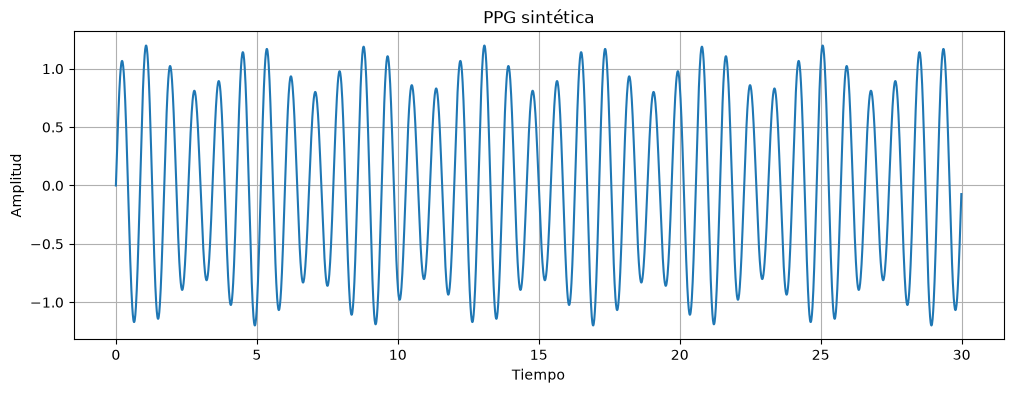

In [27]:
plt.figure(figsize=(12, 4))
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("PPG sintética")
plt.plot(t, ppg)
plt.grid()
plt.show()

In [32]:
fft = np.fft.fft(ppg)
frequencies = np.fft.fftfreq(len(ppg), 1/fs)
positive = frequencies >= 0
frequencies_positive = frequencies[positive]
fft_positive = np.abs(fft[positive])

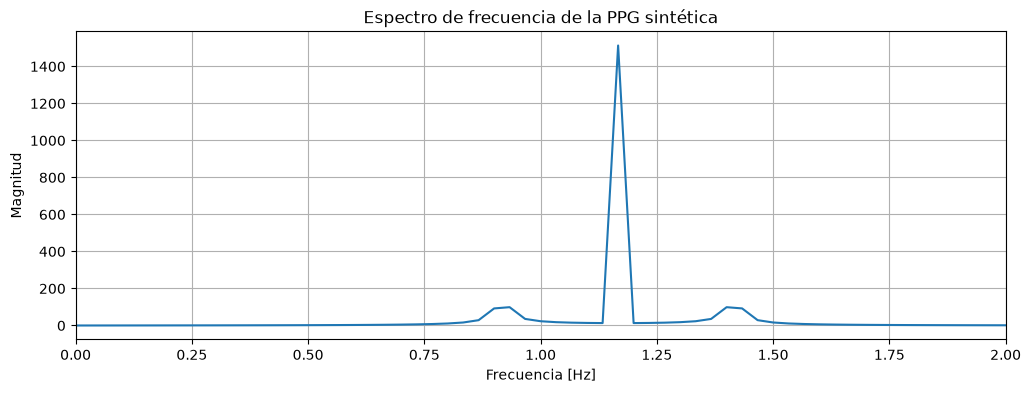

In [30]:
plt.figure(figsize=(12, 4))

plt.plot(frequencies_positive, fft_positive)

plt.xlim(0, 2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de frecuencia de la PPG sintética")

plt.grid()
plt.show()

In [37]:
indice_pico = np.argmax(fft_positive)
print(indice_pico)
frecuencia_pico = frequencies_positive[indice_pico]
print(frecuencia_pico)

35
1.1666666666666667


In [39]:
rr_band = (frequencies_positive >= 0.10) & (frequencies_positive <= 0.50)
print(rr_band)

[False False False ... False False False]


In [40]:
fft_resp = np.fft.fft(respiration)

freq_resp = np.fft.fftfreq(
    len(respiration),
    1/fs
)

positive_resp = freq_resp >= 0

freq_resp_positive = freq_resp[positive_resp]
fft_resp_positive = np.abs(fft_resp[positive_resp])

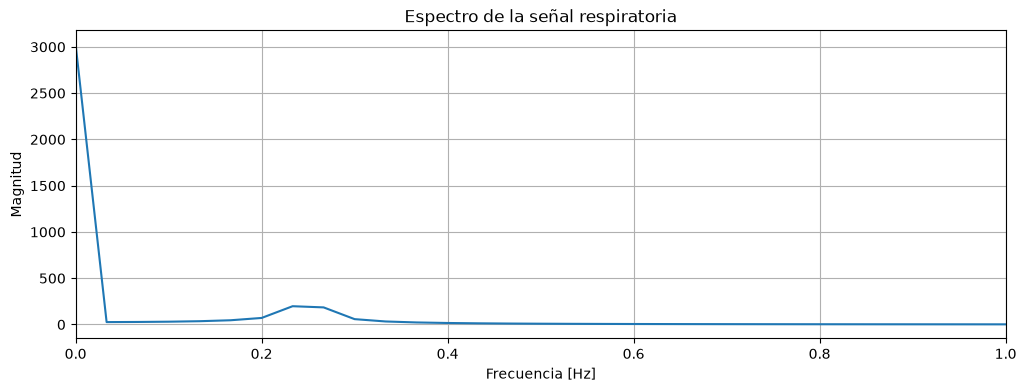

In [41]:
plt.figure(figsize=(12, 4))
plt.plot(freq_resp_positive, fft_resp_positive)
plt.xlim(0, 1)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de la señal respiratoria")
plt.grid()
plt.show()

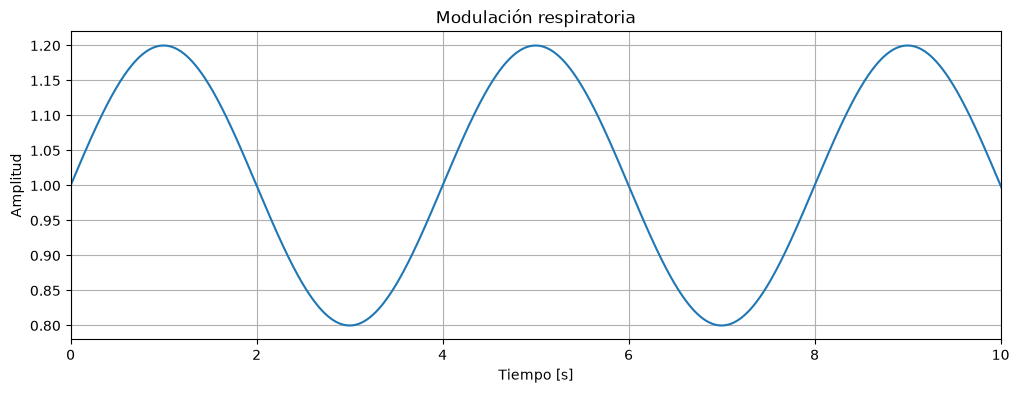

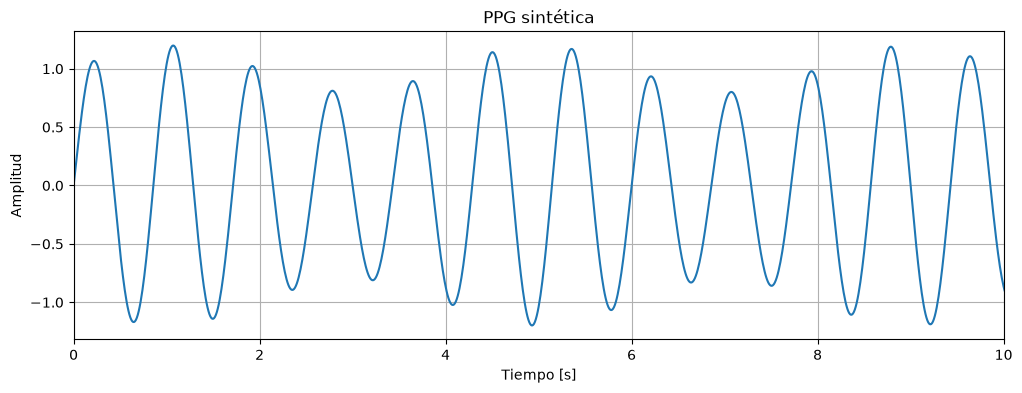

In [43]:
plt.figure(figsize=(12, 4))
plt.plot(t, respiration)
plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Modulación respiratoria")
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, ppg)
plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("PPG sintética")
plt.grid()
plt.show()

In [44]:
from scipy.signal import find_peaks

In [45]:
peaks, properties = find_peaks(
    ppg,
    distance=int(fs * 0.5)
)

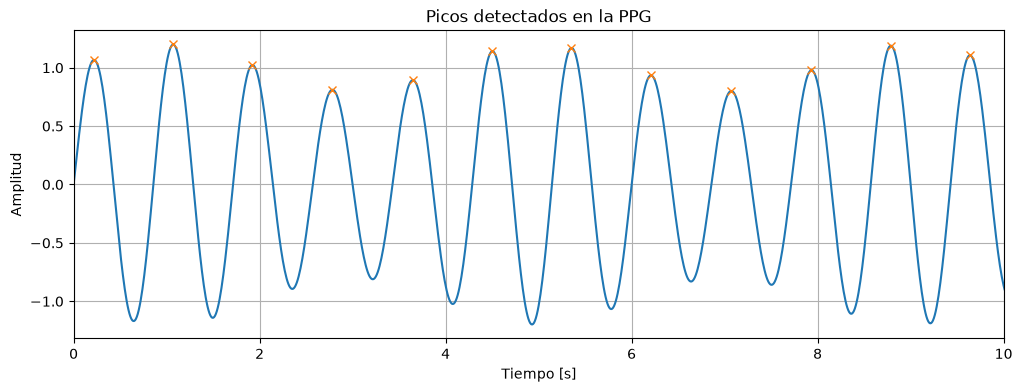

In [46]:
plt.figure(figsize=(12, 4))

plt.plot(t, ppg)
plt.plot(t[peaks], ppg[peaks], "x")

plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Picos detectados en la PPG")
plt.grid()

plt.show()

In [48]:
amplitudes = ppg[peaks]
print(amplitudes[:10])

[1.06681099 1.19872646 1.02304391 0.81111174 0.89427304 1.14142136
 1.16892386 0.93475504 0.80116388 0.97799951]


In [49]:
peaks, properties = find_peaks(
    ppg,
    distance=int(fs * 0.5)
)

amplitudes = ppg[peaks]

In [50]:
peak_times = t[peaks]

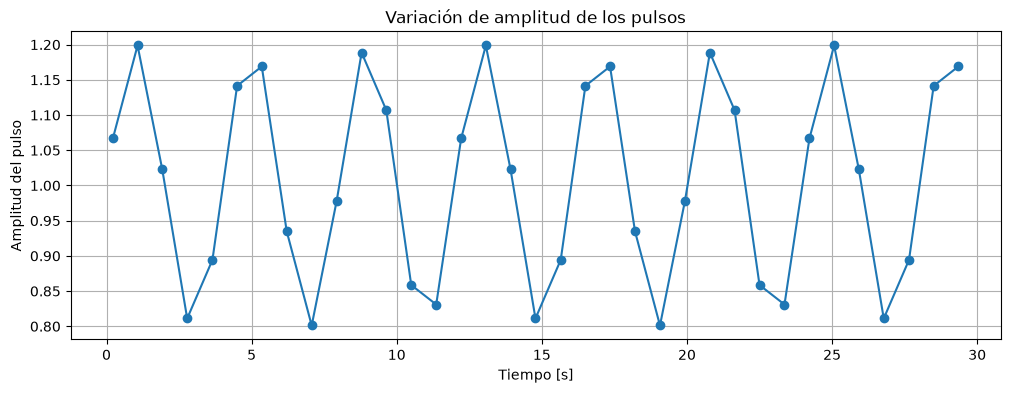

In [51]:
plt.figure(figsize=(12, 4))

plt.plot(peak_times, amplitudes, "o-")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud del pulso")
plt.title("Variación de amplitud de los pulsos")
plt.grid()

plt.show()

In [52]:
fs_resp = 10

t_resp = np.arange(
    peak_times[0],
    peak_times[-1],
    1/fs_resp
)

In [53]:
amplitudes_interp = np.interp(
    t_resp,
    peak_times,
    amplitudes
)

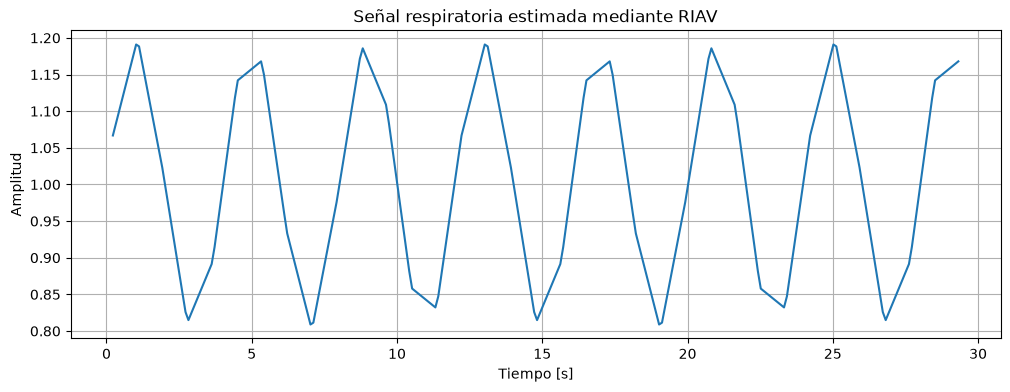

In [54]:
plt.figure(figsize=(12, 4))

plt.plot(t_resp, amplitudes_interp)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal respiratoria estimada mediante RIAV")
plt.grid()

plt.show()

In [55]:
fft_riav = np.fft.fft(amplitudes_interp)

In [56]:
frequencies_riav = np.fft.fftfreq(
    len(amplitudes_interp),
    1/fs_resp
)

In [57]:
positive_riav = frequencies_riav >= 0

frequencies_riav_positive = frequencies_riav[positive_riav]

fft_riav_positive = np.abs(
    fft_riav[positive_riav]
)

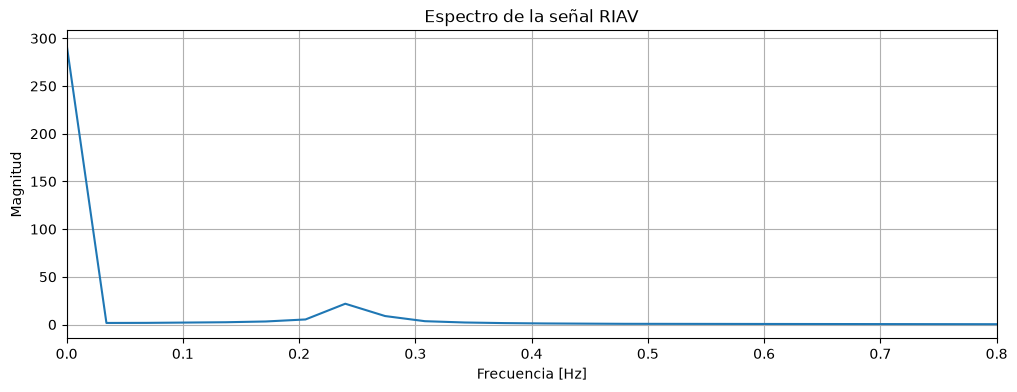

In [58]:
plt.figure(figsize=(12, 4))

plt.plot(
    frequencies_riav_positive,
    fft_riav_positive
)

plt.xlim(0, 0.8)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de la señal RIAV")

plt.grid()
plt.show()

In [59]:
indice_pico = np.argmax(fft_riav_positive)

frecuencia_rr = frequencies_riav_positive[indice_pico]

rr = frecuencia_rr * 60

print(f"Frecuencia respiratoria: {frecuencia_rr:.2f} Hz")
print(f"Frecuencia respiratoria: {rr:.1f} rpm")

Frecuencia respiratoria: 0.00 Hz
Frecuencia respiratoria: 0.0 rpm


In [60]:
amplitudes_centered = amplitudes_interp - np.mean(amplitudes_interp)

In [61]:
amplitudes_centered = amplitudes_interp - np.mean(amplitudes_interp)

fft_riav = np.fft.fft(amplitudes_centered)

In [62]:
frequencies_riav = np.fft.fftfreq(
    len(amplitudes_centered),
    1/fs_resp
)

positive_riav = frequencies_riav >= 0

frequencies_riav_positive = frequencies_riav[positive_riav]

fft_riav_positive = np.abs(
    fft_riav[positive_riav]
)

In [63]:
indice_pico = np.argmax(fft_riav_positive)

frecuencia_rr = frequencies_riav_positive[indice_pico]

rr = frecuencia_rr * 60

print(f"Frecuencia respiratoria: {frecuencia_rr:.2f} Hz")
print(f"Frecuencia respiratoria: {rr:.1f} rpm")

Frecuencia respiratoria: 0.24 Hz
Frecuencia respiratoria: 14.4 rpm


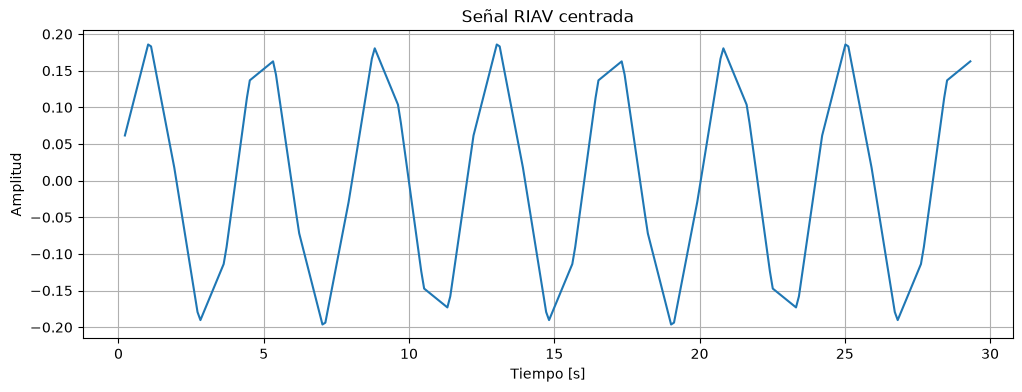

In [64]:
plt.figure(figsize=(12, 4))

plt.plot(t_resp, amplitudes_centered)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal RIAV centrada")
plt.grid()

plt.show()

In [66]:
frecuencia_rr = frequencies_riav_positive[indice_pico]
print(frecuencia_rr)

0.23972602739726026


In [67]:
indice_pico = np.argmax(fft_riav_positive)

In [75]:
rr_min = 6
rr_max = 30

f_min = rr_min / 60
f_max = rr_max / 60

rr_band = (
    (frequencies_riav_positive >= f_min) &
    (frequencies_riav_positive <= f_max)
)

frequencies_rr = frequencies_riav_positive[rr_band]
fft_rr = fft_riav_positive[rr_band]

indice_pico = np.argmax(fft_rr)

frecuencia_rr = frequencies_rr[indice_pico]

rr = frecuencia_rr * 60

print(f"Frecuencia respiratoria: {frecuencia_rr:.2f} Hz")
print(f"Frecuencia respiratoria: {rr:.1f} rpm")

Frecuencia respiratoria: 0.24 Hz
Frecuencia respiratoria: 14.4 rpm
